## Law Gender Bias - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** Law Gender Bias
* **Task :** Classification
* **Target 1:** Bias - general
* **Target 2:** Bias with a target
* **Target 3:** Bias with a target

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import random
import numpy as np

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
from typing import Any
from collections.abc import Callable
from sklearn.model_selection import train_test_split

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
def prepare_datasets(json_path: str): 

    with open(json_path, 'r') as f:
        data = json.load(f)

    train_keys, test_keys = train_test_split(list(data.keys()), test_size=0.1, random_state=42)
    train_keys, val_keys = train_test_split(train_keys, test_size=0.2, random_state=42)

    train_data = {key: data[key] for key in train_keys}
    val_data= {key: data[key] for key in val_keys}
    test_data = {key: data[key] for key in test_keys}
    
    return train_data, val_data, test_data 

In [6]:
train_data, val_data, test_data = prepare_datasets('../ap/files/annotate_filled.json')
#train_data, val_data, test_data = prepare_datasets('../lesao/files/annotate_filled.json')   

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [8]:
# Cell 3: Dataset class
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_LEN = 512
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir="transformers")

class MultiTaskDataset(Dataset):
    """
    Flexible dataset for multi-task classification from a JSON-like dict format.
    Supports multiple text chunks and multiple label fields.
    """

    def __init__(self,
                 data: dict,
                 tokenizer,
                 max_length: int = 64,
                 chunk_field: str = "vies_contexto",
                 label_extractors: dict[str, Callable[[dict[str, Any]], int]] = {},
                ) -> None:
        """
        Parameters:
        - data: loaded JSON-like dict
        - tokenizer: HuggingFace tokenizer
        - max_length: max token length
        - chunk_field: which text chunk to use (e.g., 'vies_contexto')
        - label_extractors: dictionary mapping task names to label extraction functions
        - data_type: optional, used for augmentation
        """
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.texts = []
        self.labels = {task: [] for task in label_extractors}

        for item in data.values():
            for text in item.get(chunk_field, []):
                self.texts.append(text)
                for task_name, extractor_fn in label_extractors.items():
                    label = extractor_fn(item)
                    self.labels[task_name].append(label)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer.encode_plus(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            add_special_tokens=True
        )

        item = {
            'input_ids': torch.LongTensor(encoding['input_ids']),
            'attention_mask': torch.LongTensor(encoding['attention_mask'])
        }

        for task_name in self.labels:
            item[f'{task_name}'] = torch.tensor(self.labels[task_name][idx], dtype=torch.long)

        return item

In [9]:
def key_presence_extractor(key: str, subkey: str = "") -> Callable[[dict[str, Any]], int]:
    """
    Returns a function that checks if `key` (and optionally `subkey`) is present in the sample.
    Useful for binary presence labels.
    """
    def extractor(sample: dict[str, Any]) -> int:
        if subkey != "":
            result = subkey in sample.get(key, {})
        else:
            val = sample.get(key, [""])[0] if isinstance(sample.get(key), list) else sample.get(key)
            result = bool(val)
        return int(result)
    return extractor

In [10]:
label_extractors = {
    "Bias": key_presence_extractor("vies"),
    "Bias Women": key_presence_extractor("vies_alvo", subkey="abs_mul"),
    "Bias Children": key_presence_extractor("vies_alvo", subkey="abs_cri")
}

In [11]:
trainset = MultiTaskDataset(data=train_data, tokenizer=tokenizer, label_extractors=label_extractors)
train_dataloader = DataLoader(trainset, batch_size=64, shuffle=True)

valset = MultiTaskDataset(data=val_data, tokenizer=tokenizer, label_extractors=label_extractors)
valid_dataloader = DataLoader(valset, batch_size=64)

testset = MultiTaskDataset(data=test_data, tokenizer=tokenizer, label_extractors=label_extractors)
test_dataloader = DataLoader(testset, batch_size=8)


In [12]:
model_name = "neuralmind/bert-base-portuguese-cased"

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [13]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(label_extractors.keys())

18:39:35 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:39:35 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/3 [00:00<?, ?it/s]/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.59it/s]
18:39:37 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.54it/s]
18:39:39 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  3.64it/s]
18:39:42 | DEBUG | machinemoo | Calculated weights: [0.         0.62905584 0.37094416]
18:39:42 | DEBUG | machinemoo | Importance: 0.001221102956352027
18:39:42 | DEBUG | machinemoo | Global lower bound (y*): [0.68593794 0.

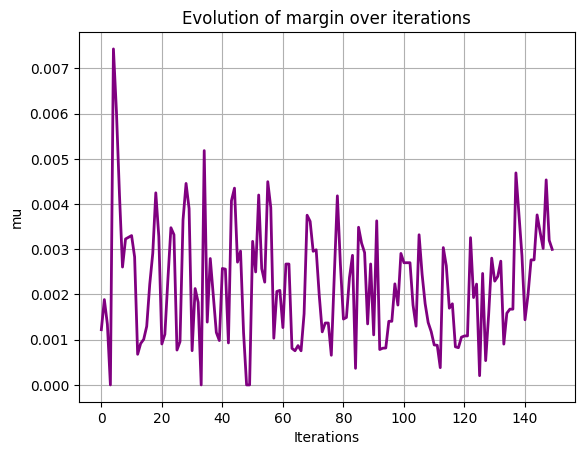

18:45:09 | INFO | machinemoo | Fit runtime: 334.22 seconds


In [14]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [15]:
objs

array([[0.49169268, 0.40118448, 0.37650216],
       [0.48052064, 0.39908393, 0.383359  ],
       [0.48665327, 0.40701849, 0.37480061],
       [0.49840537, 0.41273345, 0.37204065],
       [0.49747314, 0.40441486, 0.37599593],
       [0.50386527, 0.40205468, 0.37014069],
       [0.48044885, 0.41761885, 0.3950048 ]])

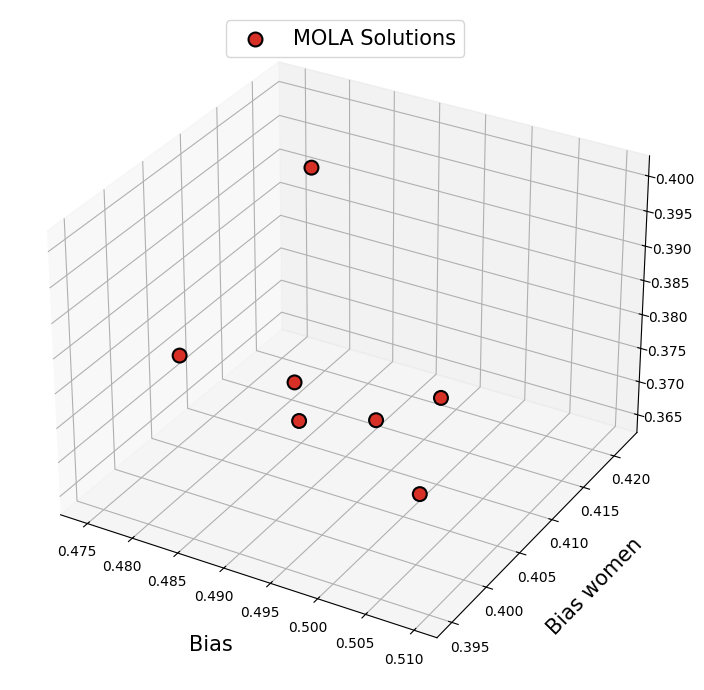

In [16]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/3_objs_mola.pdf'
            )

18:45:10 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
18:45:10 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/2 - Training:   0%|          | 0/3 [00:00<?, ?it/s]/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.44it/s]
18:45:13 | DEBUG | machinemoo | Finding 2th individual minimum
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.45it/s]
18:45:15 | DEBUG | machinemoo | Finding 3th individual minimum
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.23it/s]
18:45:18 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [-18.88364458 -24.84860945 -15.7100839 ]
18:45:18 | DEBUG | machinemoo | Calculated weights: [0. 1. 0.]
18:45:18 | DEBUG | machinemoo | Importance: 25.

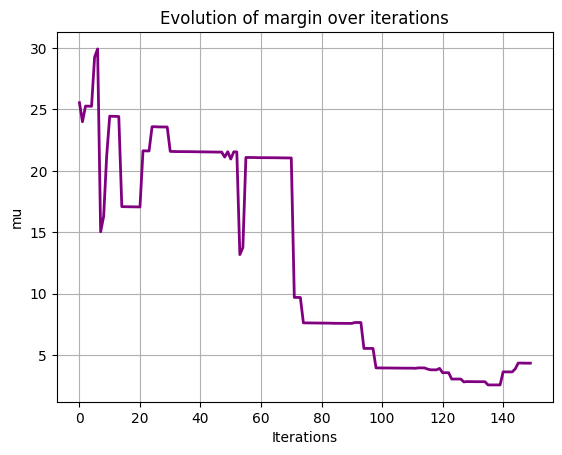

18:51:19 | INFO | machinemoo | Fit runtime: 369.09 seconds


In [17]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

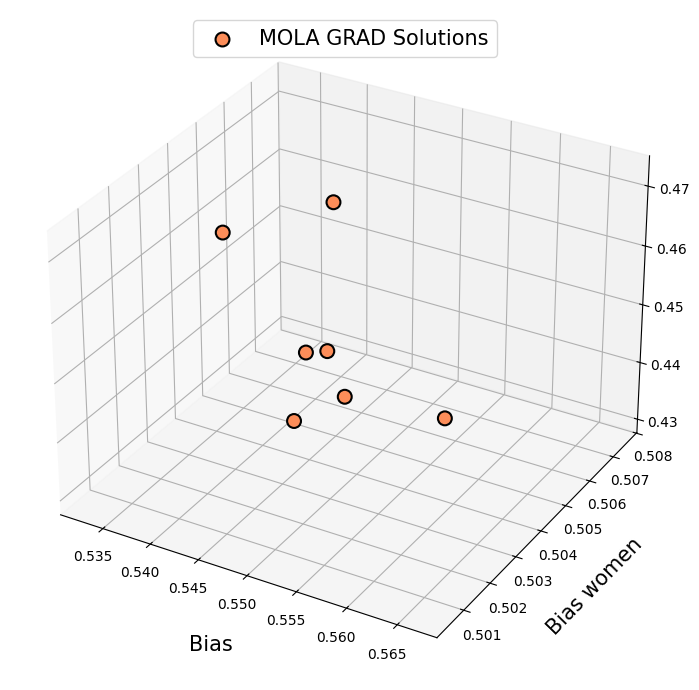

In [18]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            color=['#fc8d59'],
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            save_path='images/3_objs_mola_grad.pdf'
            )

### Random Weights

In [19]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            model_name = model_name,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

18:51:22 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'nodeGap', 'targetGap'}
18:51:22 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
18:51:22 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/2 - Training:   0%|          | 0/3 [00:00<?, ?it/s]/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.45it/s]
18:51:24 | DEBUG | machinemoo | Finding 2th individual minima
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.35it/s]
18:51:27 | DEBUG | machinemoo | Finding 3th individual minima
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.33it/s]
18:51:32 | DEBUG | machinemoo | 4th solution
Evaluating: 100%|██████████| 3/3 [00:00<00:00,  4.44it/s]
18:51:34 | DEBUG | machinemoo | 5th solution
Evaluating:

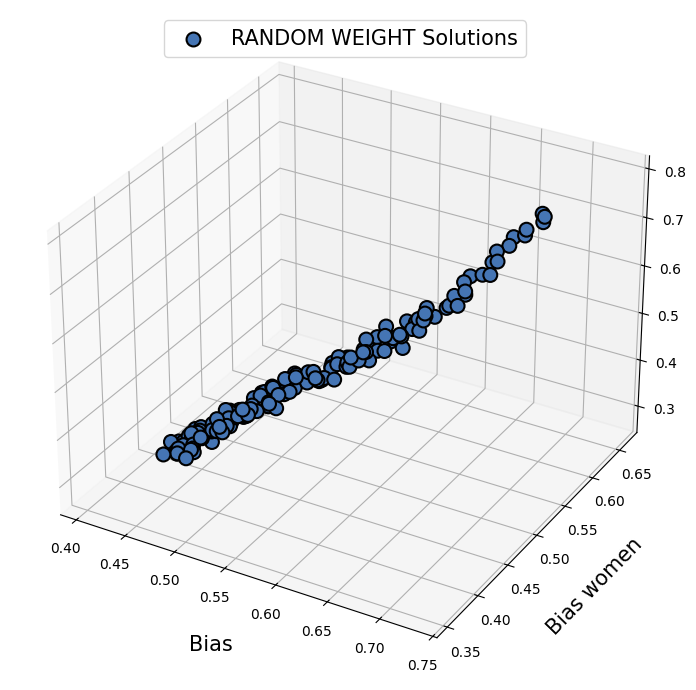

In [20]:
title="Loss Trade-offs in Law Gender Bias Detection"
plot_pareto(methods={'random_weight': objs},
            labels=task_names, 
            title=title,
            fontsize=15,
            figsize=(10,7),
            color=['#4575b4'],
            save_path='images/3_objs_rw.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

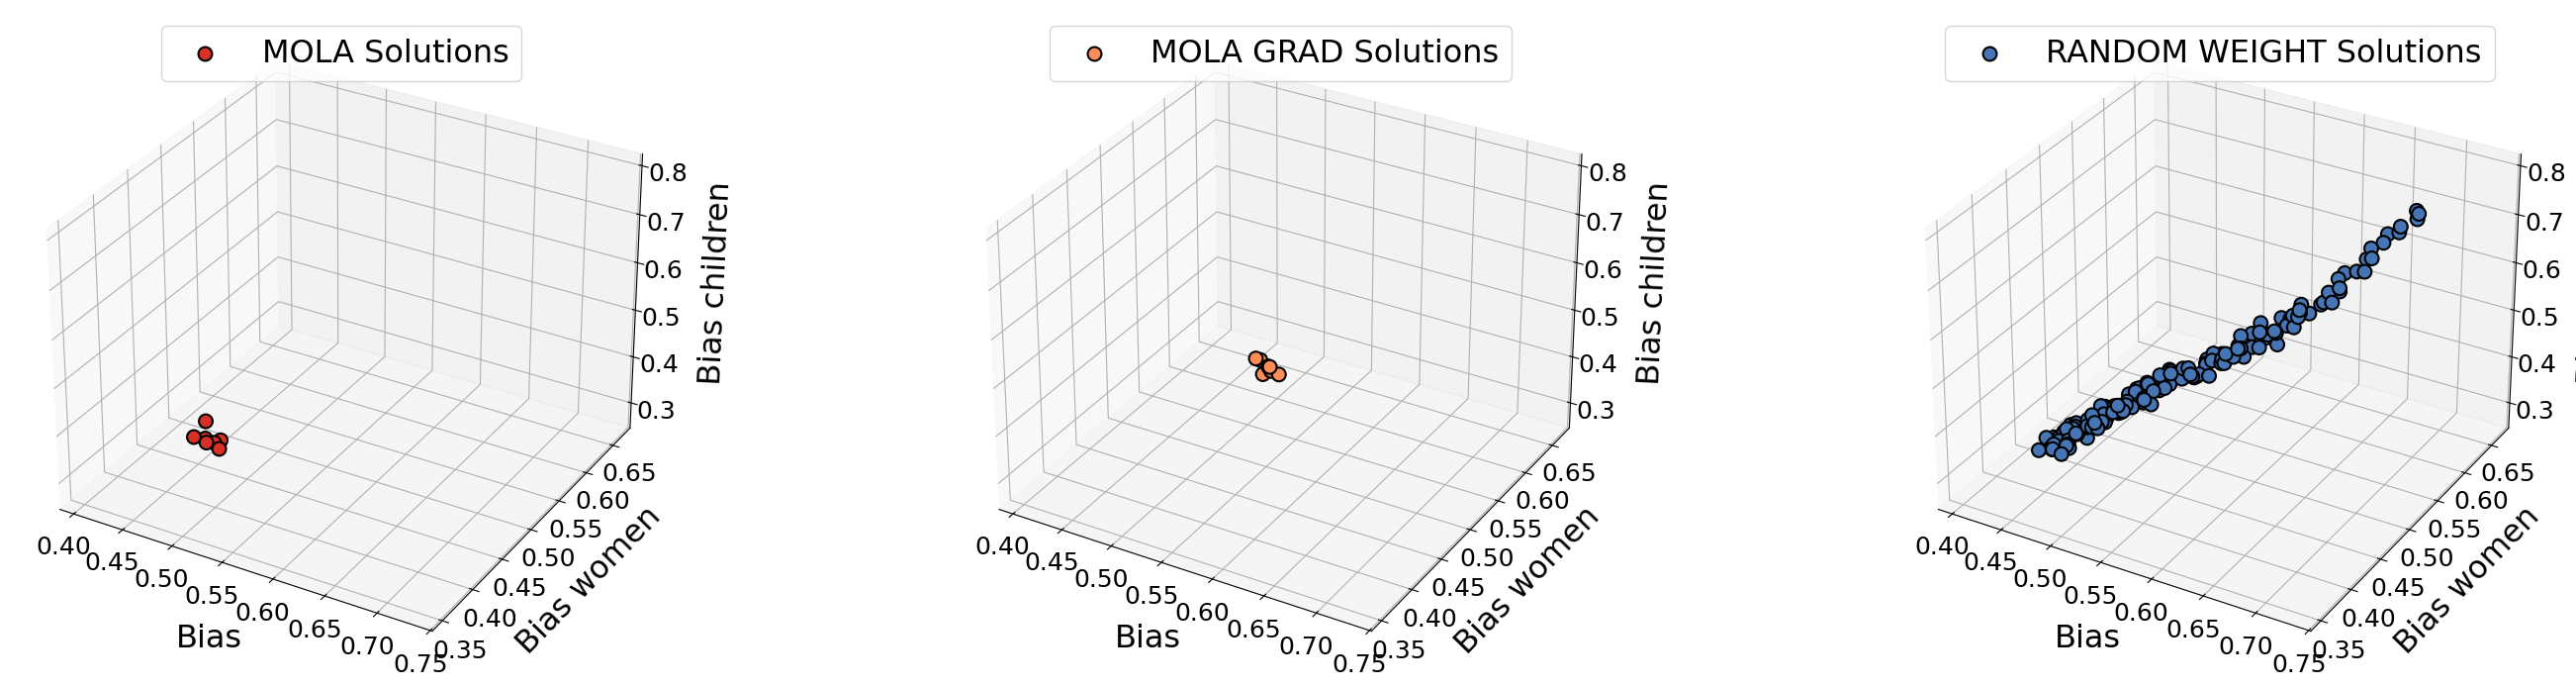

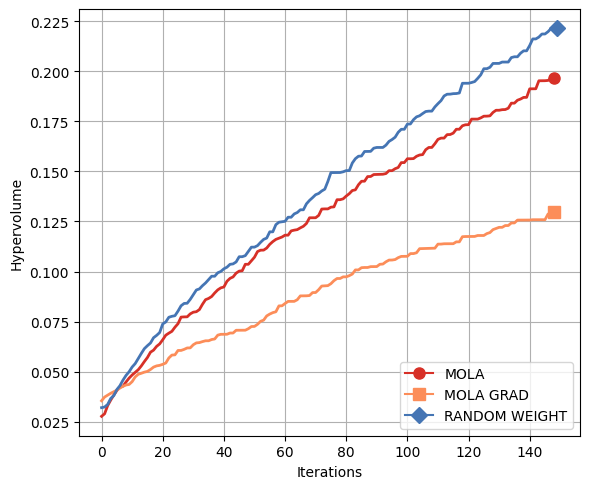

<Figure size 640x480 with 0 Axes>

In [21]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/3_objs_hypervolume.pdf")

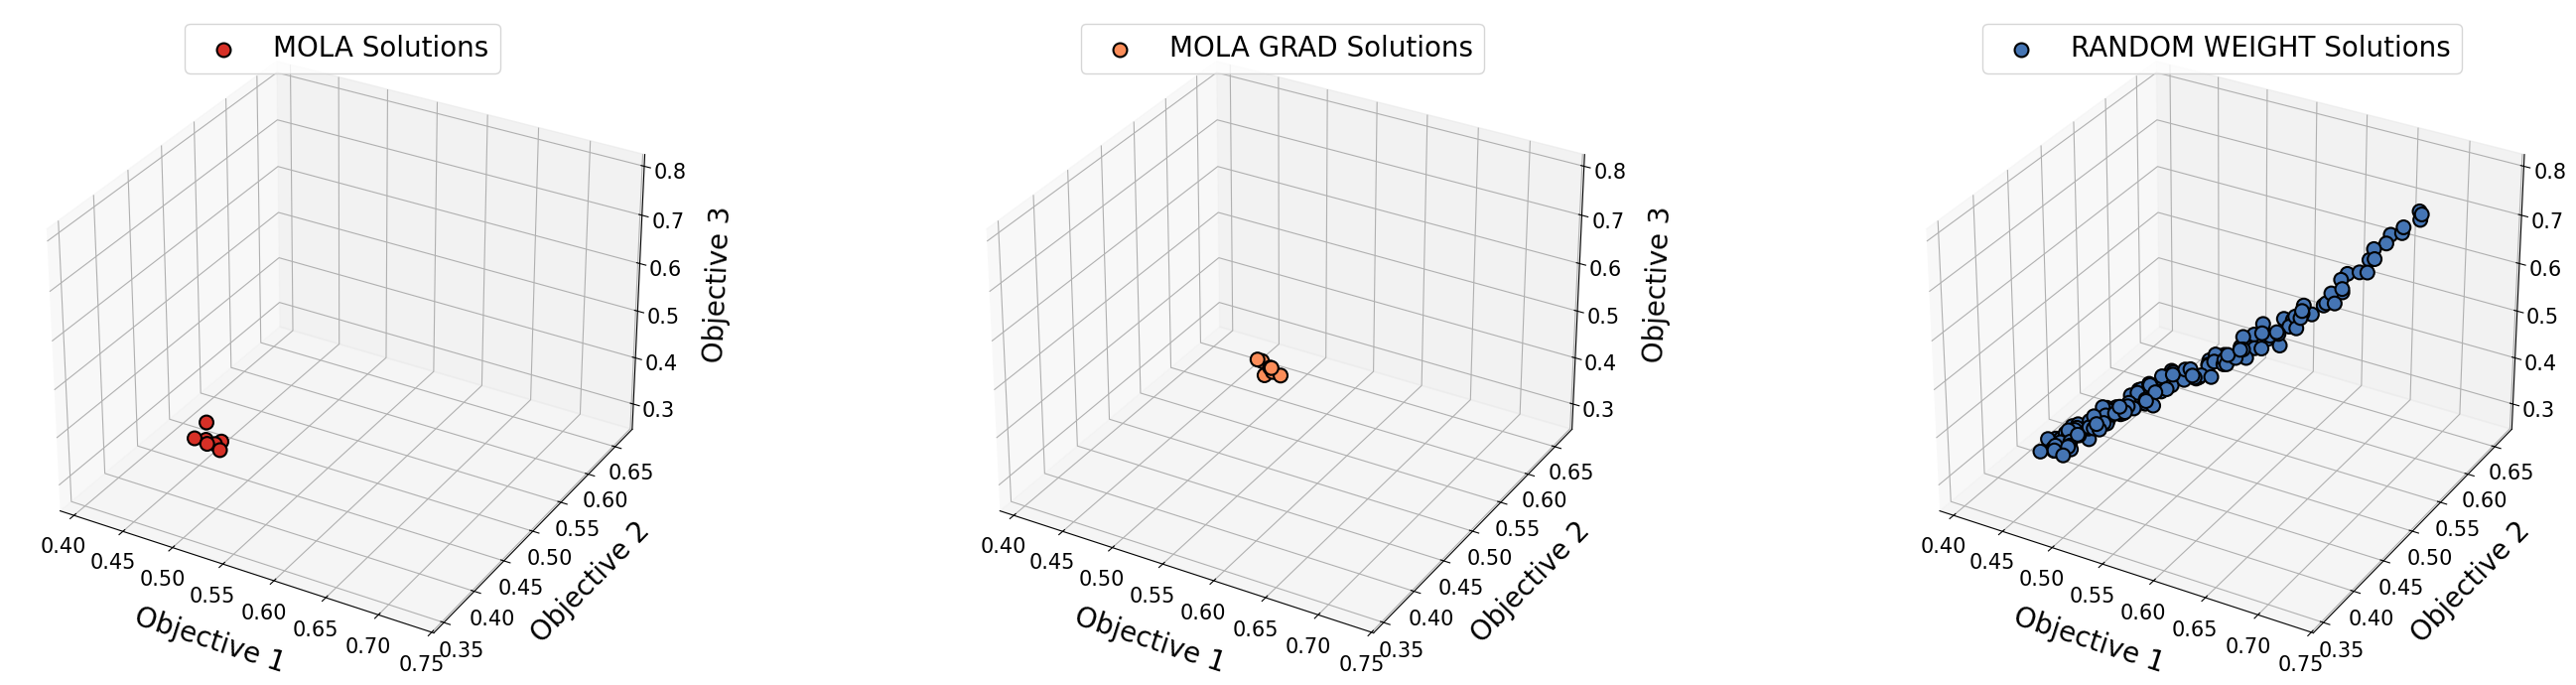

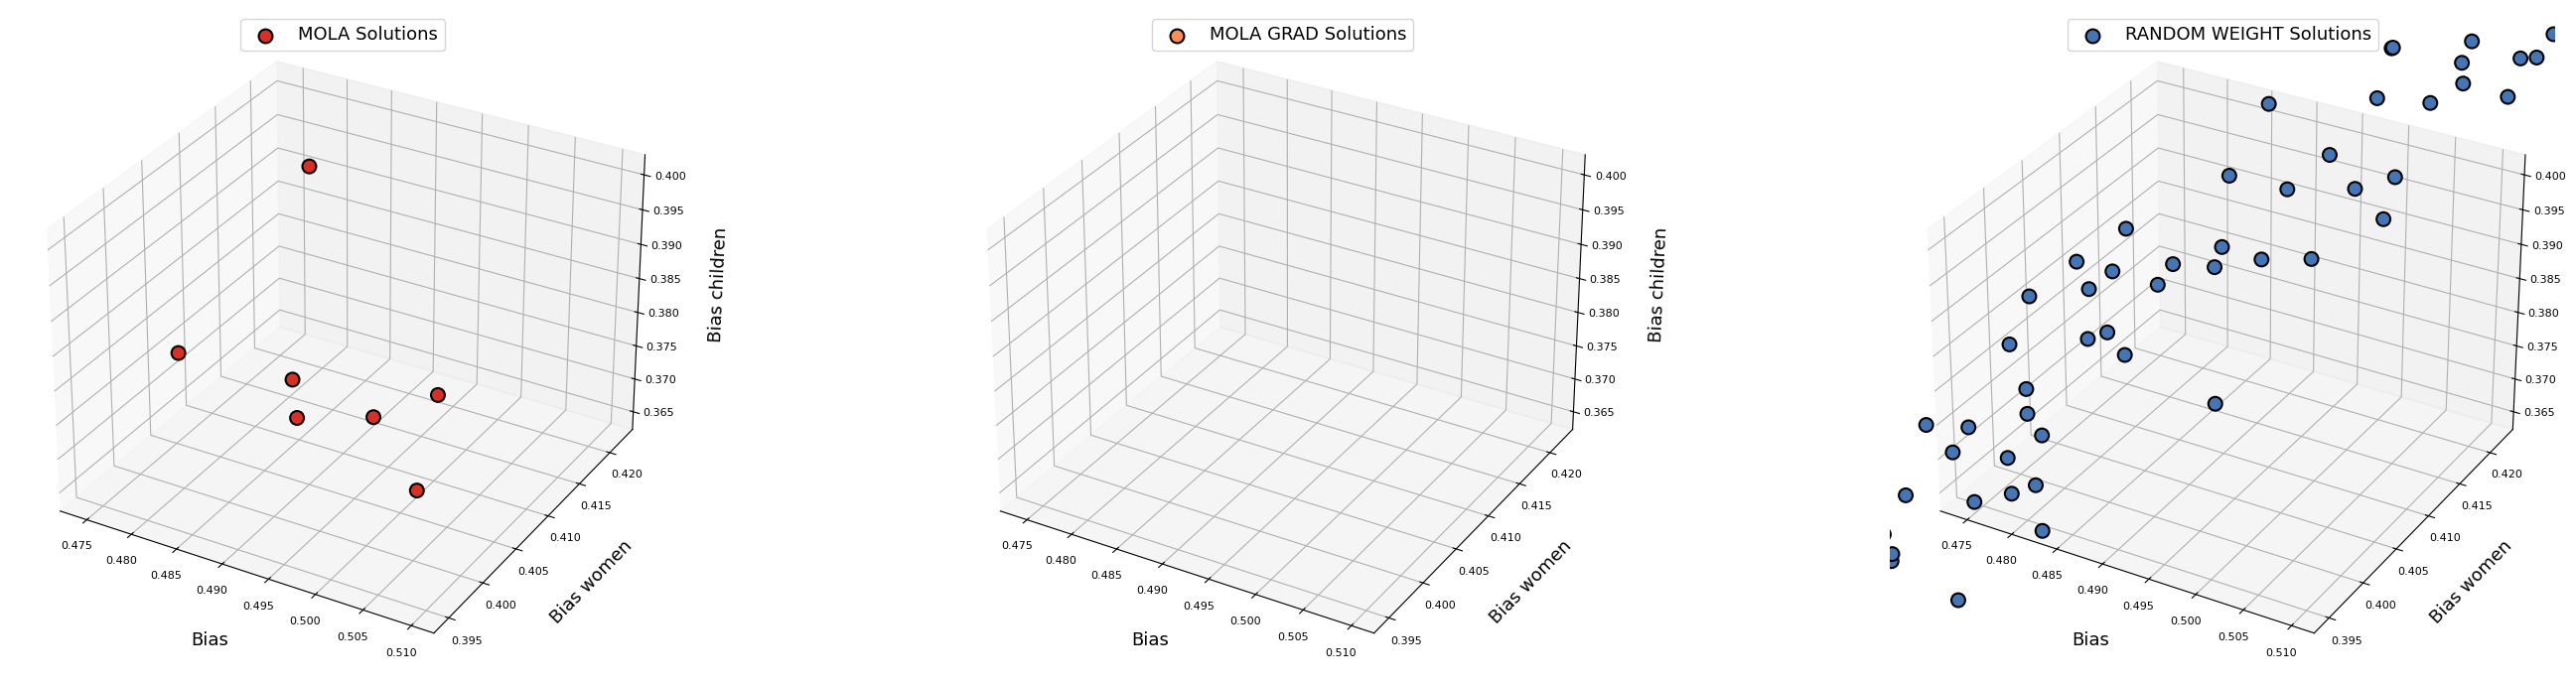

In [22]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="global")
plot_pareto_set_limit(methods=pareto_dict, 
                      axis_mode="first", 
                      title="",
                      labels=task_names, 
                      fontsize=13,
                      figsize=(10,7),
                      save_path="images/3_objs_limit.pdf")

In [ ]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

for i in range(all_data.shape[1]):
    limits.append(
        (
            all_data[:, i].min() - all_data[:, i].std(),
            all_data[:, i].max() + all_data[:, i].std(),
        )
    )
#first_objs = next(iter(pareto_dict.values()))
#x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
#y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
#z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

#limits.append((x_min, x_max))
#limits.append((y_min, y_max))
#limits.append((z_min, z_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=13,
                figsize=(10,7),
                save_path=f'images/3_objs_{method}_limit.pdf',
                limits=limits
    )

In [ ]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
from itertools import islice

second_objs = next(islice(pareto_dict.values(), 1, 2))
x_min, x_max = second_objs[:, 0].min() - second_objs[:, 0].std(), second_objs[:, 0].max() + second_objs[:, 0].std()
y_min, y_max = second_objs[:, 1].min() - second_objs[:, 1].std(), second_objs[:, 1].max() + second_objs[:, 1].std()
z_min, z_max = second_objs[:, 2].min() - second_objs[:, 2].std(), second_objs[:, 2].max() + second_objs[:, 2].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))
limits.append((z_min, z_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=15,
                figsize=(10,7),
                save_path=f'images/3_objs_{method}_limit.pdf',
                limits=limits
    )

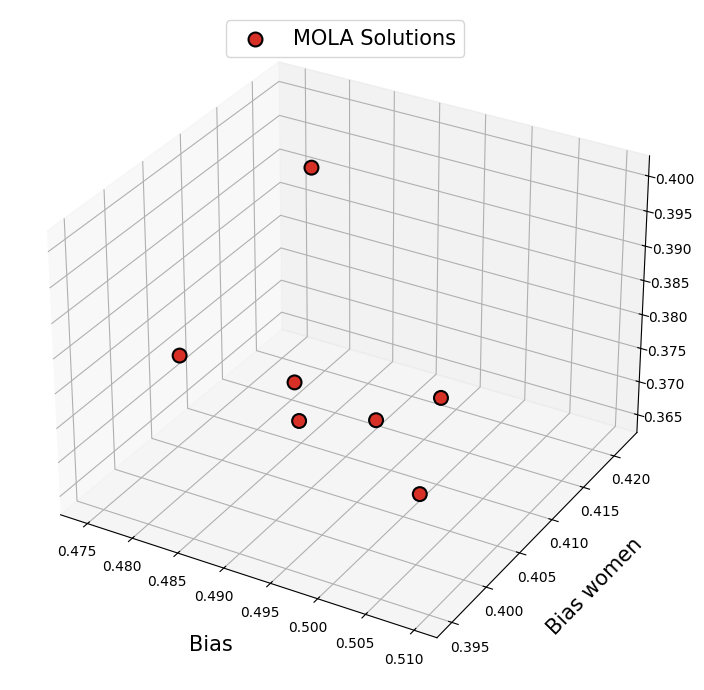

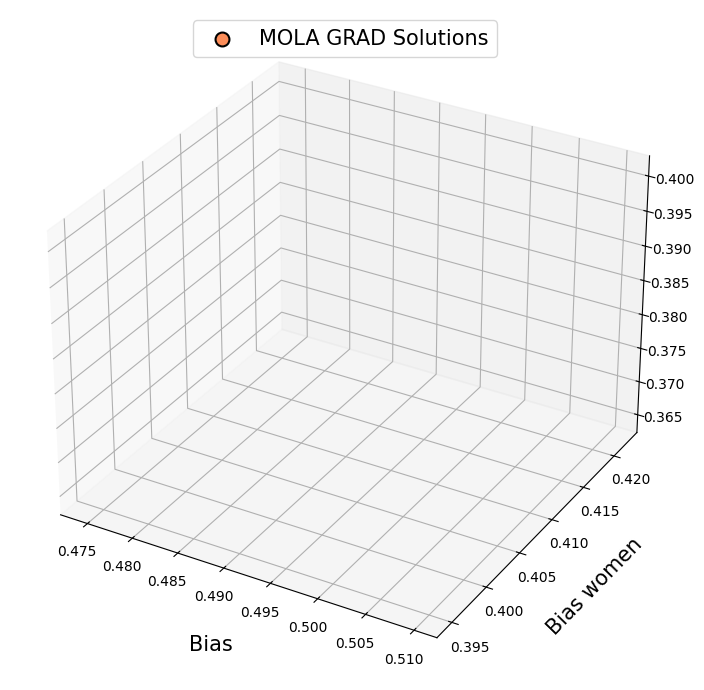

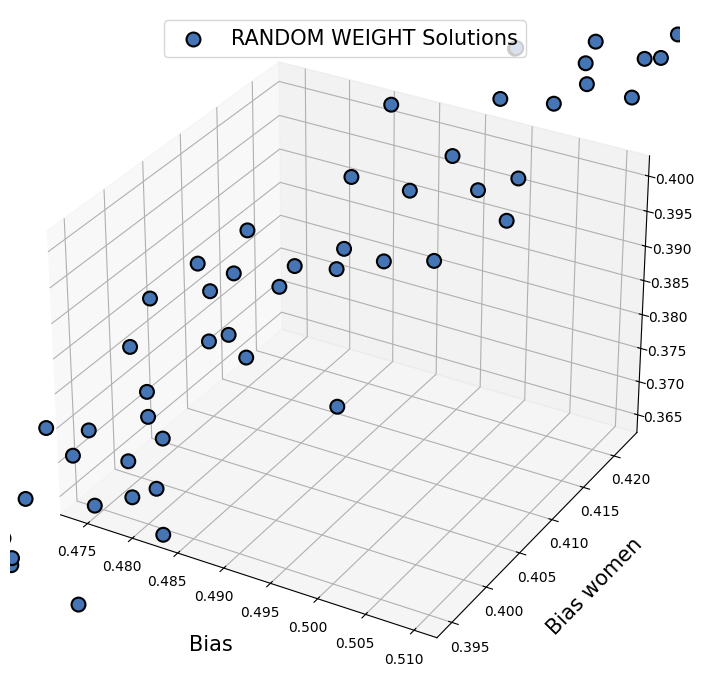

In [25]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
first_objs = next(iter(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))
limits.append((z_min, z_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=15,
                figsize=(10,7),
                save_path=f'images/3_objs_{method}_limit.pdf',
                limits=limits
    )

In [24]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 7
mola_grad: 7
Número de soluções não-dominadas (RW): 5
[[0.45974445 0.39943347 0.34376429]
 [0.44895918 0.40604596 0.35311209]
 [0.45052197 0.39211263 0.34404293]
 [0.45812224 0.41247715 0.33867123]
 [0.45870127 0.4003754  0.34122684]]
